# Preamble

In [14]:
# Imports and Globals
from models.modelspecs import *
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import mannwhitneyu

import matplotlib.ticker as mticker

import pyspike as spk
import pandas as pd
import seaborn as sns
import statsmodels.api as sm 
import statsmodels.formula.api as fml

models = ['FULLINH', 'FULLDIR']
noSearchSamples = 100
oldPalette = sns.color_palette()
#sns.set_palette(['purple', 'green'])
#sns.set_palette(['#984EA3', '#4DAF4A'])
sns.set_palette(['#7B1FA2', '#1B9E77'])


In [15]:
# Parametersets for random search
basePars = {'FULLINH':[4.*nS, 1.*nS, 100*ms, 500*ms, .467*nA, .4*nS], 'FULLDIR':[4.*nS, 2.5*nS, 100*ms, 500*ms, .412*nA, .4*nS]}
ParVars = {'FULLINH':{'rewDop':[], 'expDop':[], 'tauDA':[], 'tauDATonic':[], 'Dopamine':[], 'avgValue':[]}, 
           'FULLDIR':{'rewDop':[], 'expDop':[], 'tauDA':[], 'tauDATonic':[], 'Dopamine':[], 'avgValue':[]}}
for model in models:
    for i in range(noSearchSamples):
        with open('./DAFiring/'+model+'/ParVar'+str(i), 'rb') as f:
            parVariation = pk.load(f)
            ParVars[model]['rewDop'].append(parVariation['parset'][2])
            ParVars[model]['expDop'].append(parVariation['parset'][3])
            ParVars[model]['tauDA'].append(parVariation['parset'][4])
            ParVars[model]['tauDATonic'].append(parVariation['parset'][5])
            ParVars[model]['Dopamine'].append(parVariation['fixedCurrents']['Dopamine'])
            ParVars[model]['avgValue'].append(parVariation['fixedWeights']['avgValue'])
    # Numbers 100 are the base parsets
    ParVars[model]['rewDop'].append(basePars[model][0])
    ParVars[model]['expDop'].append(basePars[model][1])
    ParVars[model]['tauDA'].append(basePars[model][2])
    ParVars[model]['tauDATonic'].append(basePars[model][3])
    ParVars[model]['Dopamine'].append(basePars[model][4])
    ParVars[model]['avgValue'].append(basePars[model][5])

In [16]:
# Helper functions

## Letter for figures
def panel_label(ax, label, x=-0.35, y=1.1):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=14, fontweight="bold", va="top", ha="left")

## Population FANO factor as in Potjans and Diesmann 2014
def popFano(trains, binSize):
    popSpks = np.sort(np.concatenate(trains))
    popSpks = popSpks[popSpks>=10.]
    hist, _ = np.histogram(popSpks, np.arange(popSpks.min(), popSpks.max() + binSize/1000., binSize/1000.))
    return np.var(hist) / np.mean(hist)

# Experiment 1: Steady State Recording

## Extracting metrics from raw data

In [ ]:
# Computing and saving metrics
labels = ['Model', 'ParSet', 'rewDop', 'expDop', 'tauDA', 'tauDATonic', 'Dopamine', 'avgValue', 'Reward', 'TaskValue', 'Session', 'Channel', 'FiringRate', 'CoV']
popMetrics = {lab:[] for lab in labels+['SPIKE-distance', 'PopulationFANO20', 'PopulationFANO40', 'PopulationFANO60', 'PopulationFANO80', 'PopulationFANO100']}
neuMetrics = {lab:[] for lab in labels+['neuron']}

for model in models:
    for pset in range(noSearchSamples+1):
        for reward in ['Rewarded', 'Unrewarded']:
            for avgVal in ['Lo', 'Hi']: # TODO: should be 'No' as well          
                for session in range(30):
                    with open('./DAFiring/'+model+reward+avgVal+str(pset)+'/Recordings/Session'+str(session), 'rb') as f:
                        # Get all spikes after the habituation period, as well as the single spike before 10s
                        raw = [ i[np.concatenate([(i>10*second), [True]])[1:]]/second for i in pk.load(f)]
                    for ch in range(3):
                        popMetrics['Model'].append(model)
                        popMetrics['ParSet'].append(pset)
                        popMetrics['rewDop'].append(ParVars[model]['rewDop'][pset]/nS)
                        popMetrics['expDop'].append(ParVars[model]['expDop'][pset]/nS)
                        popMetrics['tauDA'].append(ParVars[model]['tauDA'][pset]/ms)
                        popMetrics['tauDATonic'].append(ParVars[model]['tauDATonic'][pset]/ms)
                        popMetrics['Dopamine'].append(ParVars[model]['Dopamine'][pset]/pamp)
                        popMetrics['avgValue'].append(ParVars[model]['avgValue'][pset]/nS)
                        popMetrics['Reward'].append(reward)
                        popMetrics['TaskValue'].append(avgVal)
                        popMetrics['Session'].append(session)
                        popMetrics['Channel'].append(ch)
                        firingRates = []
                        covs = []

                        for i in range(15):
                            neuMetrics['Model'].append(model)
                            neuMetrics['ParSet'].append(pset)
                            neuMetrics['rewDop'].append(ParVars[model]['rewDop'][pset]/nS)
                            neuMetrics['expDop'].append(ParVars[model]['expDop'][pset]/nS)
                            neuMetrics['tauDA'].append(ParVars[model]['tauDA'][pset]/ms)
                            neuMetrics['tauDATonic'].append(ParVars[model]['tauDATonic'][pset]/ms)
                            neuMetrics['Dopamine'].append(ParVars[model]['Dopamine'][pset]/pamp)
                            neuMetrics['avgValue'].append(ParVars[model]['avgValue'][pset]/nS)
                            neuMetrics['Reward'].append(reward)
                            neuMetrics['TaskValue'].append(avgVal)
                            neuMetrics['Session'].append(session)
                            neuMetrics['Channel'].append(ch)
                            neuMetrics['neuron'].append(i)
                            firingRates.append((len(raw[ch*15+i])-1)/10.)
                            neuMetrics['FiringRate'].append(firingRates[-1])
                            isi = np.diff(raw[ch*15+i])
                            covs.append(np.std(isi, ddof=1) / np.mean(isi))
                            neuMetrics['CoV'].append(covs[-1])

                        popMetrics['FiringRate'].append(np.mean(firingRates))
                        popMetrics['CoV'].append(np.mean(covs))
                        spikeWrapper = [ spk.SpikeTrain(s[1:], edges = (10.0, 20.0)) for s in raw ]
                        popMetrics['SPIKE-distance'].append(spk.spike_distance(spikeWrapper))
                        popMetrics['PopulationFANO20'].append(popFano(raw, 20))
                        popMetrics['PopulationFANO40'].append(popFano(raw, 40))
                        popMetrics['PopulationFANO60'].append(popFano(raw, 60))
                        popMetrics['PopulationFANO80'].append(popFano(raw, 80))
                        popMetrics['PopulationFANO100'].append(popFano(raw, 100))

popMetrics = pd.DataFrame(popMetrics) 
popMetrics.to_csv('./DAFiringPopulationMetrics.csv') # Takes 30 seconds
neuMetrics = pd.DataFrame(neuMetrics) 
neuMetrics.to_csv('./DAFiringNeuronMetrics.csv') # Takes 8 minutes something

WARNING    /home/roberto-sautto/Desktop/Project3/.conda/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
 [py.warnings]
WARNING    /home/roberto-sautto/Desktop/Project3/.conda/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 [py.warnings]
WARNING    /home/roberto-sautto/Desktop/Project3/.conda/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
 [py.warnings]
WARNING    /home/roberto-sautto/Desktop/Project3/.conda/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
 [py.warnings]
WARNING    /home/roberto-sautto/Desktop/Project3/.conda/lib/python3.11/site-packages

In [5]:
# Loading saved metrics
popMetrics = pd.read_csv('./DAFiringPopulationMetrics.csv', index_col=0) 
neuMetrics = pd.read_csv('./DAFiringNeuronMetrics.csv', index_col = 0)

In [5]:
# Normalising parameters for display
baseline = popMetrics[popMetrics["ParSet"] == 100].set_index("Model").drop(columns=popMetrics.columns[8:]).drop_duplicates()
x_cols = ["rewDop", "expDop", "Dopamine", "avgValue", "tauDA", "tauDATonic"]
for col in x_cols:
    popMetrics[f"{col}_norm"] = (popMetrics[col] - popMetrics["Model"].map(baseline[col])) / popMetrics["Model"].map(baseline[col])

## Preliminary Visualisation

### Firing Rates

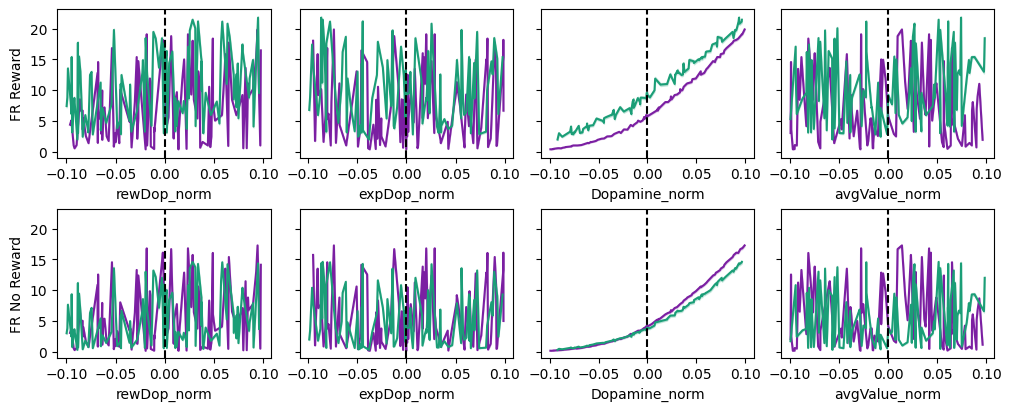

In [31]:
# Relationship Plot
measurable = 'FiringRate'
fig, axs = plt.subplots(2, 4, figsize=(10, 4), sharey=True)
tmp = popMetrics #[popMetrics['TaskValue'] == 'Hi']
rwd = tmp[tmp['Reward'] == 'Rewarded']
urd = tmp[tmp['Reward'] == 'Unrewarded']
sns.lineplot(rwd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[0][0], legend=False)
sns.lineplot(urd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[1][0], legend=False)
sns.lineplot(rwd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[0][1], legend=False)
sns.lineplot(urd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[1][1], legend=False)
sns.lineplot(rwd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[0][2], legend=False)
sns.lineplot(urd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[1][2], legend=False)
sns.lineplot(rwd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[0][3], legend=False)
sns.lineplot(urd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[1][3], legend=False)
fig.set_constrained_layout(constrained=True)
for ax in np.array(axs).flatten():
    ax.axvline(x=0, color='k', linestyle='--')
axs[0][0].set_ylabel('FR Reward')
axs[1][0].set_ylabel('FR No Reward')
pass

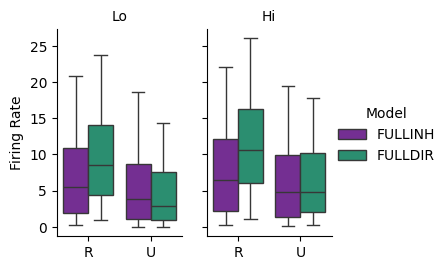

In [32]:
gf = sns.catplot(popMetrics, x='Reward', y = 'FiringRate', hue='Model', col='TaskValue', kind='box', height=3, aspect=.6)
gf.set_ylabels('Firing Rate'); gf.set_xlabels('')
gf.set_xticklabels(['R', 'U']); gf.set_titles('{col_name}')
gf.fig.subplots_adjust( wspace=0.2, )

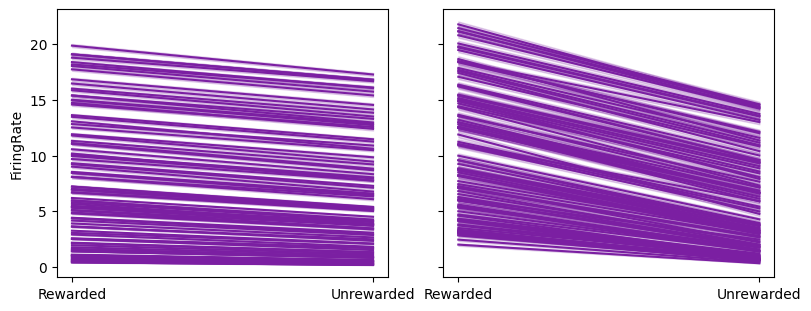

In [33]:
# For each parset: avg rewarded [line] avg unrewarded; basically ranges are datapoints
fig, axs = subplots(1,2, figsize = (8,3), sharey=True)
for i in range(101):
    sns.lineplot(popMetrics[(popMetrics['ParSet'] == i) & (popMetrics['Model'] == 'FULLINH')], x = 'Reward', hue = 'Model', y = 'FiringRate', legend = False, ax=axs[0])
axs[0].set_xlabel('')
for i in range(101):
    sns.lineplot(popMetrics[(popMetrics['ParSet'] == i)  & (popMetrics['Model'] == 'FULLDIR')], x = 'Reward', hue = 'Model', y = 'FiringRate', legend = False, ax=axs[1])
axs[1].set_xlabel('')
fig.set_constrained_layout(constrained=True)

### Coefficient of Variance

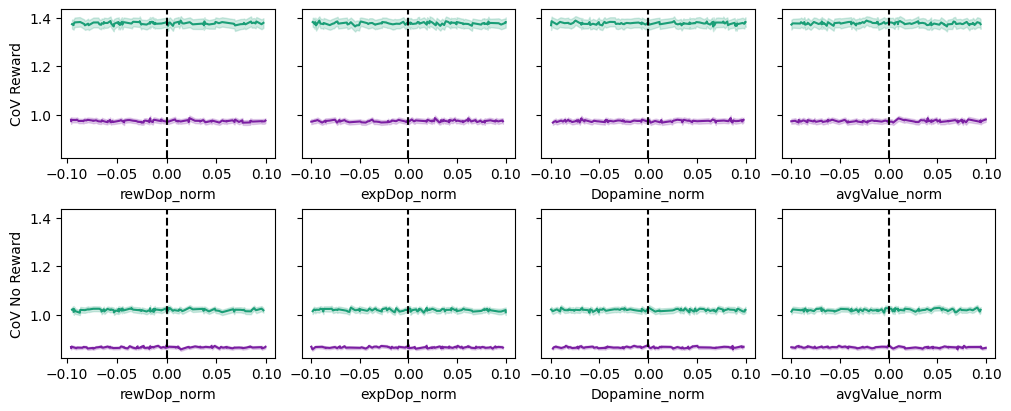

In [12]:
# Relationship Plot
measurable = 'CoV'
fig, axs = plt.subplots(2, 4, figsize=(10, 4), sharey=True)
tmp = popMetrics#[popMetrics['TaskValue'] == 'Hi']
rwd = tmp[tmp['Reward'] == 'Rewarded']
urd = tmp[tmp['Reward'] == 'Unrewarded']
sns.lineplot(rwd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[0][0], legend=False)
sns.lineplot(urd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[1][0], legend=False)
sns.lineplot(rwd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[0][1], legend=False)
sns.lineplot(urd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[1][1], legend=False)
sns.lineplot(rwd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[0][2], legend=False)
sns.lineplot(urd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[1][2], legend=False)
sns.lineplot(rwd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[0][3], legend=False)
sns.lineplot(urd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[1][3], legend=False)
fig.set_constrained_layout(constrained=True)
for ax in np.array(axs).flatten():
    ax.axvline(x=0, color='k', linestyle='--')
axs[0][0].set_ylabel('CoV Reward')
axs[1][0].set_ylabel('CoV No Reward')
pass

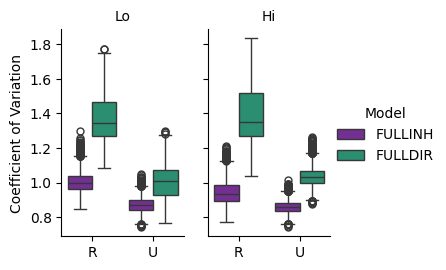

In [22]:
gf = sns.catplot(popMetrics, x='Reward', y = 'CoV', hue='Model', col='TaskValue', kind='box', height=3, aspect=.6)
gf.set_ylabels('Coefficient of Variation'); gf.set_xlabels('')
gf.set_xticklabels(['R', 'U']); gf.set_titles('{col_name}')
gf.fig.subplots_adjust( wspace=0.2, )

### SPIKE-distance

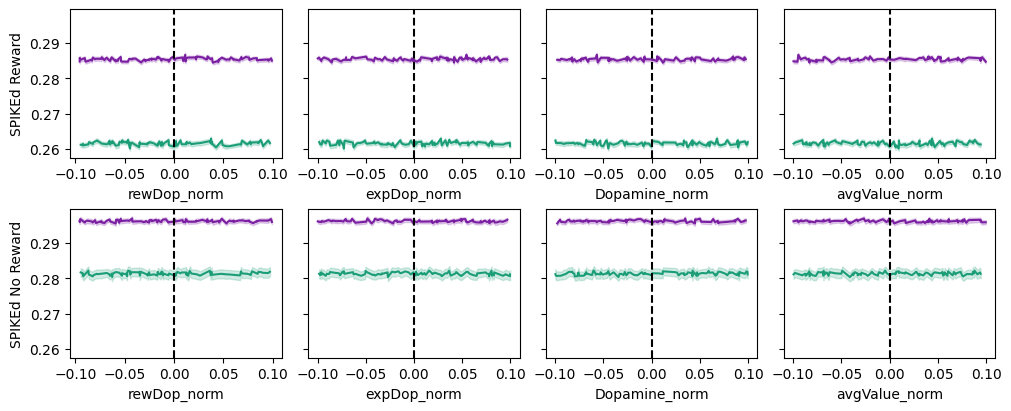

In [23]:
# Relationship Plot
measurable = 'SPIKE-distance'
fig, axs = plt.subplots(2, 4, figsize=(10, 4), sharey=True)
tmp = popMetrics#[popMetrics['TaskValue'] == 'Hi']
rwd = tmp[tmp['Reward'] == 'Rewarded']
urd = tmp[tmp['Reward'] == 'Unrewarded']
sns.lineplot(rwd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[0][0], legend=False)
sns.lineplot(urd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[1][0], legend=False)
sns.lineplot(rwd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[0][1], legend=False)
sns.lineplot(urd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[1][1], legend=False)
sns.lineplot(rwd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[0][2], legend=False)
sns.lineplot(urd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[1][2], legend=False)
sns.lineplot(rwd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[0][3], legend=False)
sns.lineplot(urd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[1][3], legend=False)
fig.set_constrained_layout(constrained=True)
for ax in np.array(axs).flatten():
    ax.axvline(x=0, color='k', linestyle='--')
axs[0][0].set_ylabel('SPIKEd Reward')
axs[1][0].set_ylabel('SPIKEd No Reward')
pass

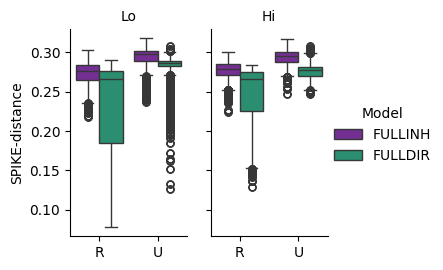

In [20]:
gf = sns.catplot(popMetrics, x='Reward', y = 'SPIKE-distance', hue='Model', col='TaskValue', kind='box', height=3, aspect=.6)
gf.set_ylabels('SPIKE-distance'); gf.set_xlabels('')
gf.set_xticklabels(['R', 'U']); gf.set_titles('{col_name}')
gf.fig.subplots_adjust( wspace=0.2, )

### PopulationFANO

In [ ]:
# Relationship Plot
measurable = 'PopulationFANO20'
fig, axs = plt.subplots(2, 4, figsize=(10, 4))
tmp = popMetrics#[popMetrics['TaskValue'] == 'Hi']
rwd = tmp[tmp['Reward'] == 'Rewarded']
urd = tmp[tmp['Reward'] == 'Unrewarded']
sns.lineplot(rwd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[0][0], legend=False)
sns.lineplot(urd, y=measurable, x = 'rewDop_norm', hue = 'Model', ax=axs[1][0], legend=False)
sns.lineplot(rwd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[0][1], legend=False)
sns.lineplot(urd, y=measurable, x = 'expDop_norm', hue = 'Model', ax=axs[1][1], legend=False)
sns.lineplot(rwd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[0][2], legend=False)
sns.lineplot(urd, y=measurable, x = 'Dopamine_norm', hue = 'Model', ax=axs[1][2], legend=False)
sns.lineplot(rwd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[0][3], legend=False)
sns.lineplot(urd, y=measurable, x = 'avgValue_norm', hue = 'Model', ax=axs[1][3], legend=False)
fig.set_constrained_layout(constrained=True)
for ax in np.array(axs).flatten():
    ax.axvline(x=0, color='k', linestyle='--')
axs[0][0].set_ylabel('PFANO20 Reward')
axs[1][0].set_ylabel('PFANO20 No Reward')

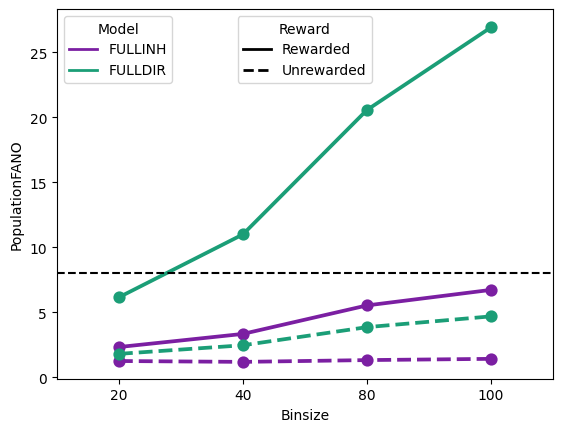

In [69]:
tmp = popMetrics[['Model', 'Reward', 'TaskValue'] + ['PopulationFANO'+str(b) for b in [20,40,80,100]]]
tmp = tmp.melt(id_vars=["Model", "Reward", "TaskValue"], var_name="Variable", value_name="PopulationFANO" )
tmp["Binsize"] = tmp["Variable"].str.extract(r"PopulationFANO(\d+)").astype(int)
gf = sns.pointplot(tmp[tmp['Reward'] == 'Rewarded'], x='Binsize', y = 'PopulationFANO', hue = 'Model', legend=False)
gf = sns.pointplot(tmp[tmp['Reward'] == 'Unrewarded'], x='Binsize', y = 'PopulationFANO', hue = 'Model', linestyles='dashed', legend=False)

model_legend = [ Line2D([0], [0], color="C0", lw=2, label="FULLINH"), Line2D([0], [0], color="C1", lw=2, label="FULLDIR") ]
reward_legend = [ Line2D([0], [0], color="k", lw=2, linestyle="-", label="Rewarded"), Line2D([0], [0], color="k", lw=2, linestyle="--", label="Unrewarded") ]

# prima legenda
leg1 = plt.gca().legend(
    handles=model_legend,
    title="Model",
    loc="upper left"
)

# aggiungila manualmente (IMPORTANTE)
plt.gca().add_artist(leg1)
plt.gca().axhline(8, color='black', linestyle='--')

# seconda legenda
plt.gca().legend( handles=reward_legend, title="Reward", loc="upper center")

### ISI Histograms

In [17]:
# Loading Interspike Intervals
intervals = {mod:{rew:{val:[] for val in ['Lo', 'Hi']} for rew in ['Rewarded', 'Unrewarded']} for mod in models}

for model in models:
    for reward in ['Rewarded', 'Unrewarded']:
        for avgVal in ['Lo', 'Hi']:
            isis = []
            for session in range(30):
                with open('./DAFiringOld/'+model+reward+avgVal+'100/Recordings/Session'+str(session), 'rb') as f:
                    # Get all spikes after the habituation period, as well as the single spike before 10s
                    raw = [ i[np.concatenate([(i>10*second), [True]])[1:]]/ms for i in pk.load(f)]
                for i in raw:
                    isi = np.diff(i)
                    isis.append(isi[isi < 800])
            intervals[model][reward][avgVal] = np.hstack(isis)

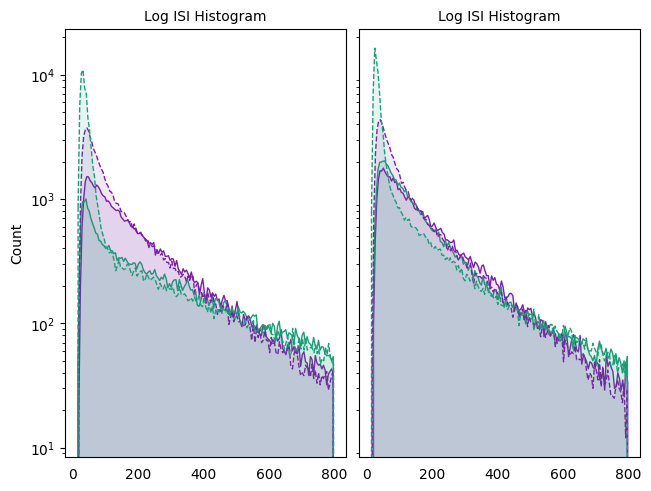

In [18]:
# ISI histograms
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True)
axs = np.array(axs).flatten()
modTitle = {'FULLDIR':'Direct', 'FULLINH':'Disinhibition'}
valTitle = {'Lo':'Low Value', 'Hi':'High Value'}
count = 0
#for reward in ['Rewarded', 'Unrewarded']:
for avgVal in ['Lo', 'Hi']:
    sns.histplot(intervals["FULLINH"]['Unrewarded'][avgVal], ax = axs[count], binwidth=5, element="poly", alpha = .1)
    sns.histplot(intervals["FULLDIR"]['Unrewarded'][avgVal], ax = axs[count], binwidth=5, element="poly", alpha = .1) 
    sns.histplot(intervals["FULLINH"]['Rewarded'][avgVal], ax = axs[count], binwidth=5, element="poly", alpha = .1, linestyle='--')
    sns.histplot(intervals["FULLDIR"]['Rewarded'][avgVal], ax = axs[count], binwidth=5, element="poly", alpha = .1, linestyle='--') 
    title = reward+' | '+modTitle[model]+' | '+valTitle[avgVal]
    axs[count].set_title("Log ISI Histogram", {'fontsize':'medium'})
    axs[count].set_yscale('log')
    axs[count].tick_params(left=(count%2==0), bottom = ((count==6) or (count==7)))
    count+= 1

fig.set_constrained_layout(constrained=True)

## Analysis

### Firing Rates

In [ ]:
# Firing Rates - Unrewarded
print("Unrewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Unrewarded']
reg = fml.ols('FiringRate ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm)', data = tmp).fit()
reg.summary()

In [ ]:
# Firing Rates - Rewarded
print("Rewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Rewarded']
reg = fml.ols('FiringRate ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm+rewDop_norm+expDop_norm)', data = tmp).fit()
reg.summary()

### Coefficient of Variation

In [ ]:
# Firing Rates - Unrewarded
print("Unrewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Unrewarded']
reg = fml.ols('CoV ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm)', data = tmp).fit()
reg.summary()

In [ ]:
# Firing Rates - Rewarded
print("Rewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Rewarded']
reg = fml.ols('CoV ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm+rewDop_norm+expDop_norm)', data = tmp).fit()
reg.summary()

# Run separately for models

### SPIKE-distance

In [ ]:
# Firing Rates - Unrewarded
print("Unrewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Unrewarded']
reg = fml.ols('SPIKEdistance ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm)', data = tmp).fit()
reg.summary()

In [ ]:
# Firing Rates - Rewarded
print("Rewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Rewarded']
reg = fml.ols('SPIKEdistance ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm+rewDop_norm+expDop_norm)', data = tmp).fit()
reg.summary()

# Run separately for models

### PopulationFANO

In [63]:
# Firing Rates - Unrewarded
print("Unrewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Unrewarded']
reg = fml.ols('PopulationFANO20 ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm)', data = tmp).fit()
reg.summary()

Unrewarded Data


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       PopulationFANO20   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     6791.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:25:23   Log-Likelihood:                -4030.4
No. Observations:               36360   AIC:                             8077.
Df Residuals:                   36352   BIC:                             8145.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  1.8285      0.003    643.686      0.000       1.823       1.834
C(Model)[T.FULLINH]                       -0.6314      0.004   -157.278      0.000      -0.639      -0.624
C(TaskValue)[T.Hi]                        -0.0052      0.004     -1.305      0.192      -0.013       0.003
C(Model)[T.FULLINH]:C(TaskValue)[T.Hi]     0.1364      0.006     24.052      0.000       0.125       0.148
Dopamine_norm                             -3.1660      0.036    -87.840      0.000      -3.237      -3.095
C(Model)[T.FULLINH]:Dopamine_norm          3.9601      0.050     78.575      0.000       3.861       4.059
avgValue_norm                              0.9417      0.035     26.564      0.000       0.872       1.011
C(Model)[T.FULLINH]:avgValue_norm         -0.5106      0.050    -10.261      0.000      -0.608      -0.413
==============================================================================
Omnibus:                     1730.541   Durbin-Watson:                   0.219
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5697.372
Skew:                           0.145   Prob(JB):                         0.00
Kurtosis:                       4.917   Cond. No.                         54.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Firing Rates - Rewarded
print("Rewarded Data"); tmp = popMetrics[popMetrics['Reward'] == 'Rewarded']
reg = fml.ols('PopulationFANO20 ~ C(Model)*(C(TaskValue)+Dopamine_norm+avgValue_norm+rewDop_norm+expDop_norm)', data = tmp).fit()
reg.summary()

# Run separately for models

### Categorical Significance

In [ ]:
def select_df(df, sel):
    filters = {}
    if 'FULLINH' in sel: filters['Model'] = 'FULLINH'
    elif 'FULLDIR' in sel: filters['Model'] = 'FULLDIR'

    if 'Rewarded' in sel: filters['Reward'] = 'Rewarded'
    elif 'Unrewarded' in sel: filters['Reward'] = 'Unrewarded'

    if 'Hi' in sel: filters['TaskValue'] = 'Hi'
    elif 'Lo' in sel: filters['TaskValue'] = 'Lo'

    sub = df.copy()
    for k, v in filters.items():
        sub = sub[sub[k] == v]
    return sub

def dfTtest(df, variable, sel1, sel2, equal_var=False):
    d1 = select_df(df, sel1)[variable]
    d2 = select_df(df, sel2)[variable]

    t, p = mannwhitneyu(d1, d2, equal_var=equal_var)

    print('variable'+variable+': '+sel1+'('+d1.mean()+')/'+sel2+'('+d2.mean()+'); p = '+p)

In [10]:
smallMetrics = pd.DataFrame(popMetrics[['Model', 'Reward', 'FiringRate', 'CoV', 'SPIKE-distance', 'PopulationFANO20']])
catAvgs = smallMetrics.groupby(['Model','Reward'], observed=True).agg([ 'mean', 'median', 'std'])
catAvgs['CoV']

mean    median       std
Model   Reward                                  
FULLDIR Rewarded    1.382289  1.325516  0.446047
        Unrewarded  0.953799  0.944586  0.188432
FULLINH Rewarded    0.924502  0.943716  0.199193
        Unrewarded  0.796729  0.822618  0.125952

In [9]:
smallMetrics = pd.DataFrame(popMetrics[['Model', 'Reward', 'TaskValue', 'FiringRate', 'CoV', 'SPIKE-distance', 'PopulationFANO20']])
catAvgs = smallMetrics.groupby(['Model','Reward','TaskValue'], observed=True).agg([ 'mean', 'median', 'std'])
catAvgs['CoV']

mean    median       std
Model   Reward     TaskValue                              
FULLDIR Rewarded   Hi         1.387872  1.330498  0.445261
                   Lo         1.376707  1.316364  0.446785
        Unrewarded Hi         0.965149  0.982989  0.177535
                   Lo         0.941266  0.907291  0.199034
FULLINH Rewarded   Hi         0.901664  0.920417  0.192972
                   Lo         0.947539  0.975764  0.202698
        Unrewarded Hi         0.795608  0.822651  0.130200
                   Lo         0.797923  0.822579  0.121259

In [ ]:
dfTtest(smallMetrics, 'FiringRate', '')

In [10]:
popMetrics["Reward"] = pd.Categorical(popMetrics["Reward"], categories=["Unrewarded", "Rewarded"], ordered=True)
popMetrics["TaskValue"] = pd.Categorical(popMetrics["TaskValue"], categories=["Lo", "Hi"], ordered=True)
reg = fml.ols('FiringRate ~ C(Model)*(C(TaskValue)+C(Reward))', data = popMetrics).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             FiringRate   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     2245.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:24:43   Log-Likelihood:            -2.2460e+05
No. Observations:               72720   AIC:                         4.492e+05
Df Residuals:                   72714   BIC:                         4.493e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     4.4914      0.048     93.115      0.000       4.397       4.586
C(Model)[T.FULLINH]                           0.9777      0.068     14.333      0.000       0.844       1.111
C(TaskValue)[T.Hi]                            1.8464      0.056     33.151      0.000       1.737       1.956
C(Reward)[T.Rewarded]                         5.0111      0.056     89.972      0.000       4.902       5.120
C(Model)[T.FULLINH]:C(TaskValue)[T.Hi]       -1.0764      0.079    -13.665      0.000      -1.231      -0.922
C(Model)[T.FULLINH]:C(Reward)[T.Rewarded]    -3.5174      0.079    -44.656      0.000      -3.672      -3.363
==============================================================================
Omnibus:                     8489.460   Durbin-Watson:                   0.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5432.133
Skew:                           0.549   Prob(JB):                         0.00
Kurtosis:                       2.233   Cond. No.                         8.34
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
popMetrics["Reward"] = pd.Categorical(popMetrics["Reward"], categories=["Unrewarded", "Rewarded"], ordered=True)
popMetrics["TaskValue"] = pd.Categorical(popMetrics["TaskValue"], categories=["Lo", "Hi"], ordered=True)
reg = fml.ols('CoV ~  C(Model)*(C(TaskValue)+C(Reward))', data = popMetrics).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CoV   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     8815.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:24:53   Log-Likelihood:                -8907.6
No. Observations:               67109   AIC:                         1.783e+04
Df Residuals:                   67103   BIC:                         1.788e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.9447      0.003    358.936      0.000       0.940       0.950
C(Model)[T.FULLINH]                          -0.1348      0.004    -35.317      0.000      -0.142      -0.127
C(TaskValue)[T.Hi]                            0.0173      0.003      5.850      0.000       0.011       0.023
C(Reward)[T.Rewarded]                         0.4289      0.003    145.159      0.000       0.423       0.435
C(Model)[T.FULLINH]:C(TaskValue)[T.Hi]       -0.0428      0.004    -10.028      0.000      -0.051      -0.034
C(Model)[T.FULLINH]:C(Reward)[T.Rewarded]    -0.3015      0.004    -70.470      0.000      -0.310      -0.293
==============================================================================
Omnibus:                     6133.656   Durbin-Watson:                   0.422
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13762.375
Skew:                           0.575   Prob(JB):                         0.00
Kurtosis:                       4.897   Cond. No.                         8.48
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
popMetrics["Reward"] = pd.Categorical(popMetrics["Reward"], categories=["Unrewarded", "Rewarded"], ordered=True)
popMetrics["TaskValue"] = pd.Categorical(popMetrics["TaskValue"], categories=["Lo", "Hi"], ordered=True)
popMetrics["SPIKEdistance"] = popMetrics["SPIKE-distance"]
reg = fml.ols("SPIKEdistance ~  C(Model)*(C(TaskValue)+C(Reward))", data = popMetrics).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          SPIKEdistance   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                 1.080e+04
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:27:45   Log-Likelihood:             2.0155e+05
No. Observations:               72720   AIC:                        -4.031e+05
Df Residuals:                   72714   BIC:                        -4.030e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.2811      0.000   2044.209      0.000       0.281       0.281
C(Model)[T.FULLINH]                           0.0099      0.000     50.772      0.000       0.009       0.010
C(TaskValue)[T.Hi]                           -0.0020      0.000    -12.714      0.000      -0.002      -0.002
C(Reward)[T.Rewarded]                        -0.0250      0.000   -157.336      0.000      -0.025      -0.025
C(Model)[T.FULLINH]:C(TaskValue)[T.Hi]        0.0020      0.000      9.072      0.000       0.002       0.002
C(Model)[T.FULLINH]:C(Reward)[T.Rewarded]     0.0111      0.000     49.216      0.000       0.011       0.011
==============================================================================
Omnibus:                    30289.831   Durbin-Watson:                   0.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           194608.810
Skew:                          -1.891   Prob(JB):                         0.00
Kurtosis:                      10.066   Cond. No.                         8.34
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [62]:
popMetrics["Reward"] = pd.Categorical(popMetrics["Reward"], categories=["Unrewarded", "Rewarded"], ordered=True)
popMetrics["TaskValue"] = pd.Categorical(popMetrics["TaskValue"], categories=["Lo", "Hi"], ordered=True)
reg = fml.ols("PopulationFANO20 ~  C(Model)*(C(TaskValue)+C(Reward))", data = popMetrics).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       PopulationFANO20   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                 7.840e+04
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:22:09   Log-Likelihood:                -90104.
No. Observations:               72720   AIC:                         1.802e+05
Df Residuals:                   72714   BIC:                         1.803e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     2.1406      0.008    282.088      0.000       2.126       2.155
C(Model)[T.FULLINH]                          -0.7896      0.011    -73.577      0.000      -0.811      -0.769
C(TaskValue)[T.Hi]                           -0.6522      0.009    -74.432      0.000      -0.669      -0.635
C(Reward)[T.Rewarded]                         4.3491      0.009    496.352      0.000       4.332       4.366
C(Model)[T.FULLINH]:C(TaskValue)[T.Hi]        0.4785      0.012     38.616      0.000       0.454       0.503
C(Model)[T.FULLINH]:C(Reward)[T.Rewarded]    -3.2738      0.012   -264.195      0.000      -3.298      -3.250
==============================================================================
Omnibus:                     8016.123   Durbin-Watson:                   0.082
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            38958.345
Skew:                           0.439   Prob(JB):                         0.00
Kurtosis:                       6.477   Cond. No.                         8.34
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Experiment 2: Learning Task

## Full learning with t = 90

In [9]:
# Concatenating and saving weights data
weightsData = []
for model in models:
    for pset in range(noSearchSamples+1):
        wts = pd.read_csv('./LearningTask/'+model+'TrialsMi'+str(pset)+'_s30t90/WeightsStats.csv')
        wts['Model'] = [model]*len(wts)
        wts['ParSet'] = [pset]*len(wts)
        wts['rewDop'] = [ParVars[model]['rewDop'][pset]]*len(wts)/nS
        wts['expDop'] = [ParVars[model]['expDop'][pset]]*len(wts)/nS
        wts['tauDA'] = [ParVars[model]['tauDA'][pset]]*len(wts)/ms
        wts['tauDATonic'] = [ParVars[model]['tauDATonic'][pset]]*len(wts)/ms
        wts['Dopamine'] = [ParVars[model]['Dopamine'][pset]]*len(wts)/pamp
        wts['avgValue'] = [ParVars[model]['avgValue'][pset]]*len(wts)/pamp
        weightsData.append(wts)
weightsData = pd.concat(weightsData).drop(columns=['Trial', 'nId'])
weightsData.to_csv('./LearningTaskWeights.csv')

FileNotFoundError: [Errno 2] No such file or directory: './LearningTask/FULLINHTrialsMi0_s30t90/WeightsStats.csv'

In [11]:
weightsData = pd.read_csv('./LearningTaskWeights.csv', index_col=0)

## Preliminary Visualization

Text(0.5, 1.0, 'FULLINH')

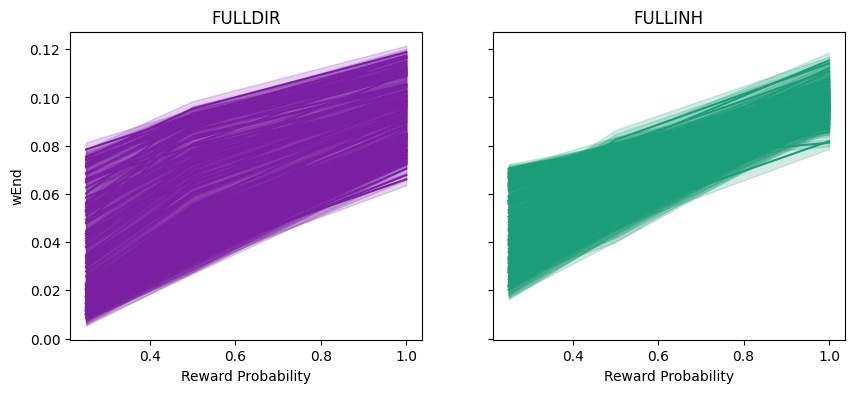

In [11]:
# Weights
fig, axs = plt.subplots(1,2, sharey=True, figsize=(10,4))
for ps in range(101):
    tmp = weightsData[weightsData['ParSet']==ps]
    sns.lineplot(tmp[tmp['Model']=='FULLDIR'], x='Reward Probability', y='wEnd', ax=axs[0], color='C0')
    sns.lineplot(tmp[tmp['Model']=='FULLINH'], x='Reward Probability', y='wEnd', ax=axs[1], color='C1')
axs[0].set_title('FULLDIR')
axs[1].set_title('FULLINH')

In [12]:
# Success Metrics
results = []
for (model, parset), g in weightsData.groupby(["Model", "ParSet"]):
    m = fml.ols("wEnd ~ C(Q('Reward Probability'))", data=g).fit()
    aov = sm.stats.anova_lm(m, typ=2)
    results.append({ "Model": model, "ParSet": parset, "Success": aov.loc["C(Q('Reward Probability'))", "PR(>F)"] < .05,
    })
success = pd.DataFrame(results)[['Model', 'Success']].groupby('Model').agg('sum')

tukey = []
for (model, parset), g in weightsData.groupby(["Model", "ParSet"]):
    tuk = sm.stats.multicomp.pairwise_tukeyhsd(g["wEnd"], g["Reward Probability"])
    for res in tuk.summary().data[1:]:
        pair = str(res[0])+'-'+str(res[1])
        tukey.append({"Model": model, "ParSet": parset, "Pair": pair, "significant": res[5] < 0.05 })
tukey = pd.DataFrame(tukey)
success['Pairs'] = tukey[['Model', 'significant']].groupby('Model').agg('sum')['significant']

tmp = tukey[['Model', 'ParSet','significant']].groupby(['Model', 'ParSet']).agg('sum').reset_index()
tmp['StrictSuccess'] = tmp['significant'] > 2
success['Strict'] = tmp[['Model', 'StrictSuccess']].groupby('Model').agg('sum')['StrictSuccess']
success['FPairs'] = success['Pairs'] - success['Strict']*3
success['FPairs%'] = success['FPairs']*100 / success['Pairs'] 
success

,Success,Pairs,Strict,FPairs,FPairs%
Model,,,,,
FULLDIR,101,211,16,163,77.251185
FULLINH,101,222,37,111,50.000000


In [13]:
# Slopes per ParSet
slopes = []
for (model, parset), g in weightsData.groupby(["Model", "ParSet"]):
    X = sm.add_constant(g["Reward Probability"]); y = g["wEnd"]
    res = sm.OLS(y, X).fit()
    slopes.append({ "Model": model, "ParSet": parset, "slope": res.params["Reward Probability"] })
slopes = pd.DataFrame(slopes)

In [14]:
# Slope Variance
sVar = []
for (model, parset, session), g in weightsData.groupby(["Model", "ParSet", "Session"]):
    X = sm.add_constant(g["Reward Probability"]); y = g["wEnd"]
    res = sm.OLS(y, X).fit()
    sVar.append({
        "Model": model,
        "ParSet": parset,
        "slope": res.params["Reward Probability"],
    })
sVar = pd.DataFrame(sVar).groupby(['Model', 'ParSet']).agg('std').rename(columns={'slope':'Average SD'}).reset_index()

# Pretty Plots

IndexError: index 3 is out of bounds for axis 1 with size 3

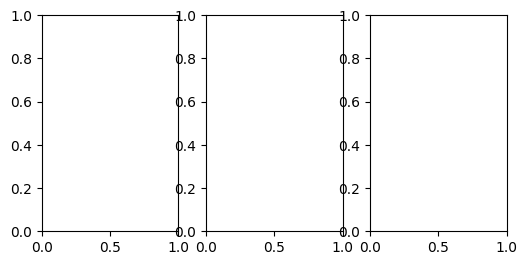

In [ ]:
# Metrics overview
#fig, axs = plt.subplots(2,4, figsize=(6,7))
fig = plt.figure(figsize=(6, 5))
gs = GridSpec(7, 4, figure=fig)
axs = [fig.add_subplot(gs[0:4, 0]), fig.add_subplot(gs[0:4, 1]), fig.add_subplot(gs[0:4, 2]), fig.add_subplot(gs[0:4, 3]), fig.add_subplot(gs[4:7, 0]), fig.add_subplot(gs[4:7, 1]), fig.add_subplot(gs[4:7, 2]), fig.add_subplot(gs[4:7, 3]) ]
 

axs = np.array(axs).flatten()
metHi = popMetrics[popMetrics['TaskValue'] == 'Hi']
metLo = popMetrics[popMetrics['TaskValue'] == 'Lo']
# Firing Rate
sns.boxplot(metLo, x='Reward', y = 'FiringRate', hue='Model', legend=False, ax = axs[0])
axs[0].set_ylabel('Firing Rate (Hz)'); axs[0].set_xlabel('')
panel_label(axs[0], 'A', -.5); axs[0].set_title('              Expected\nLow', {'fontsize':rcParams["axes.labelsize"]})
axs[0].set_ylim((axs[0].get_ylim()[0], axs[0].get_ylim()[1]*1.5))
tmp = popMetrics[(popMetrics['Model'] == 'FULLINH') & (popMetrics['TaskValue'] == 'Lo')]
diffDis = tmp[tmp['Reward'] == 'Rewarded']['FiringRate'].array - tmp[tmp['Reward'] == 'Unrewarded']['FiringRate'].array
tmp = popMetrics[(popMetrics['Model'] == 'FULLDIR') & (popMetrics['TaskValue'] == 'Lo')]
diffDir = tmp[tmp['Reward'] == 'Rewarded']['FiringRate'].array - tmp[tmp['Reward'] == 'Unrewarded']['FiringRate'].array
ins0 = inset_axes(axs[0], width='65%', height='17%', loc='upper right')
sns.histplot(diffDis, ax = ins0, bins=100, element="poly", alpha = .1)
sns.histplot(diffDir, ax = ins0, bins=100, element="poly", alpha = .1)
ins0.tick_params(labelsize=6); ins0.set_xticks([0, 4, 8])
#ins0.set_ylabel(r'# UR $\Delta$Rate', {'fontsize':8}); ins0.set_xlabel('')
ins0.set_ylabel(''); ins0.set_xlabel('')

sns.boxplot(metHi, x='Reward', y = 'FiringRate', hue='Model', legend=False, ax = axs[1])
axs[1].sharey(axs[0]); axs[1].set_title('Reward            \n High', {'fontsize':rcParams["axes.labelsize"]})
axs[1].set_ylabel(''); axs[1].tick_params(labelleft=False, left=False); axs[1].set_xlabel('')
tmp = popMetrics[(popMetrics['Model'] == 'FULLINH') & (popMetrics['TaskValue'] == 'Hi')]
diffDis = tmp[tmp['Reward'] == 'Rewarded']['FiringRate'].array - tmp[tmp['Reward'] == 'Unrewarded']['FiringRate'].array
tmp = popMetrics[(popMetrics['Model'] == 'FULLDIR') & (popMetrics['TaskValue'] == 'Hi')]
diffDir = tmp[tmp['Reward'] == 'Rewarded']['FiringRate'].array - tmp[tmp['Reward'] == 'Unrewarded']['FiringRate'].array
ins1 = inset_axes(axs[1], width='65%', height='17%', loc='upper right')
sns.histplot(diffDis, ax = ins1, bins=100, element="poly", alpha = .1)
sns.histplot(diffDir, ax = ins1, bins=100, element="poly", alpha = .1)
ins1.tick_params(labelsize=6); ins1.set_xticks([0, 4, 8])
#ins1.set_ylabel(r'# UR $\Delta$Rate', {'fontsize':8}); ins1.set_xlabel('')
ins1.set_ylabel(''); ins1.set_xlabel('')

axs[0].axhline(5., linestyle='--', color='black', linewidth=.5)
axs[1].axhline(5., linestyle='--', color='black', linewidth=.5)

# Coefficient of Variation
sns.boxplot(metLo, x='Reward', y = 'CoV', hue='Model', legend=False, ax = axs[2])
axs[2].set_ylabel('Coefficient of Variation (a.u.)'); axs[2].set_xlabel('')
panel_label(axs[2], 'B', -.5); axs[2].set_title('              Expected\nLow', {'fontsize':rcParams["axes.labelsize"]})
axs[2].axhline(1., linestyle='--', color='black', linewidth=.5)
axs[2].set_ylim((axs[2].get_ylim()[0], axs[2].get_ylim()[1]*1.4))
ins2 = inset_axes(axs[2], width='65%', height='17%', loc='upper right')
#sns.histplot(intervals["FULLINH"]['Unrewarded']["Lo"], ax = ins2, binwidth=5, element="poly", alpha = .1, linestyle='--')
#sns.histplot(intervals["FULLDIR"]['Unrewarded']["Lo"], ax = ins2, binwidth=5, element="poly", alpha = .1, linestyle='--') 
sns.histplot(intervals["FULLINH"]['Rewarded']["Lo"], ax = ins2, binwidth=5, element="poly", alpha = .1)
sns.histplot(intervals["FULLDIR"]['Rewarded']["Lo"], ax = ins2, binwidth=5, element="poly", alpha = .1) 
ins2.set_yscale('log')
#ins2.set_ylabel('#ISI', {'fontsize':8}); ins2.set_xlabel('')
ins2.set_ylabel(''); ins2.set_xlabel('')
ins2.tick_params(labelsize=6); ins2.set_xticks([0, 250, 500, 750])

sns.boxplot(metHi, x='Reward', y = 'CoV', hue='Model', legend=False, ax = axs[3])
axs[3].sharey(axs[2]); axs[3].set_title('Reward            \n High', {'fontsize':rcParams["axes.labelsize"]})
axs[3].set_ylabel(''); axs[3].tick_params(labelleft=False, left=False); axs[3].set_xlabel('')
axs[3].axhline(1., linestyle='--', color='black', linewidth=.5)
ins3 = inset_axes(axs[3], width='65%', height='17%', loc='upper right')
#sns.histplot(intervals["FULLINH"]['Unrewarded']["Hi"], ax = ins3, binwidth=5, element="poly", alpha = .1, linestyle='--')
#sns.histplot(intervals["FULLDIR"]['Unrewarded']["Hi"], ax = ins3, binwidth=5, element="poly", alpha = .1, linestyle='--') 
sns.histplot(intervals["FULLINH"]['Rewarded']["Hi"], ax = ins3, binwidth=5, element="poly", alpha = .1)
sns.histplot(intervals["FULLDIR"]['Rewarded']["Hi"], ax = ins3, binwidth=5, element="poly", alpha = .1) 
ins3.sharey(ins2)
ins3.set_yscale('log')
#ins3.set_ylabel('#ISI', {'fontsize':8}); ins3.set_xlabel('')
ins3.set_ylabel(''); ins3.set_xlabel('')
ins3.tick_params(labelsize=6); ins3.set_xticks([0, 250, 500, 750])

# SPIKE-distance
sns.boxplot(metLo, x='Reward', y = 'SPIKE-distance', hue='Model', legend=False, ax = axs[4])
panel_label(axs[4], 'C', -.5); axs[4].set_title('')
axs[4].set_ylabel('SPIKE-distance ($×10^{-1}$ a.u.)')
axs[4].set_xticklabels(['Yes', 'No'])
axs[4].set_xlabel('Rewarded')
axs[4].yaxis.set_major_formatter( mticker.FuncFormatter(lambda y, _: f"{y*10:.1f}") )
sns.boxplot(metHi, x='Reward', y = 'SPIKE-distance', hue='Model', legend=True, ax = axs[5])
axs[5].sharey(axs[4]); axs[5].set_title('')
axs[5].set_ylabel(''); axs[5].tick_params(labelleft=False, left=False)
axs[5].set_xticklabels(['Yes', 'No'])
axs[5].set_xlabel('Rewarded')
handles, labels = axs[5].get_legend_handles_labels()
new_labels = {"FULLDIR": "Direct", "FULLINH": "Disinhibition"}
labels = [new_labels.get(l, l) for l in labels]
axs[5].legend(handles, labels, title = '', loc='lower right', fontsize=8, handlelength=1.2)
# Synchrony
sns.boxplot(metLo, x='Reward', y = 'PopulationFANO20', hue='Model', legend=False, ax = axs[6])
axs[6].set_ylabel('\nPopulation Synchrony (a.u.)')
panel_label(axs[6], 'D', -.5); axs[6].set_title('')
axs[6].axhline(8., linestyle='--', color='black', linewidth=.5)
axs[6].set_xticklabels(['Yes', 'No'])
axs[6].set_xlabel('Rewarded')
sns.boxplot(metHi, x='Reward', y = 'PopulationFANO20', hue='Model', legend=False, ax = axs[7])
axs[7].sharey(axs[6]); axs[7].set_title('')
axs[7].set_ylabel(''); axs[7].tick_params(labelleft=False, left=False)
axs[7].set_xticklabels(['Yes', 'No'])
axs[7].set_xlabel('Rewarded')
axs[7].axhline(8., linestyle='--', color='black', linewidth=.5)

for i, ax in enumerate(axs):
    ax.relim()
    ax.autoscale_view()
    if i < 4: ax.set_xticks([])
for ax in [ins0, ins1, ins2, ins3]:
    ax.relim()
    ax.autoscale_view()

fig.set_constrained_layout(constrained=True)
#fig.subplots_adjust(wspace=.1)
fig.savefig('./Plots/populationMetrics.svg', format='svg')


# Do analysis of who wins and why

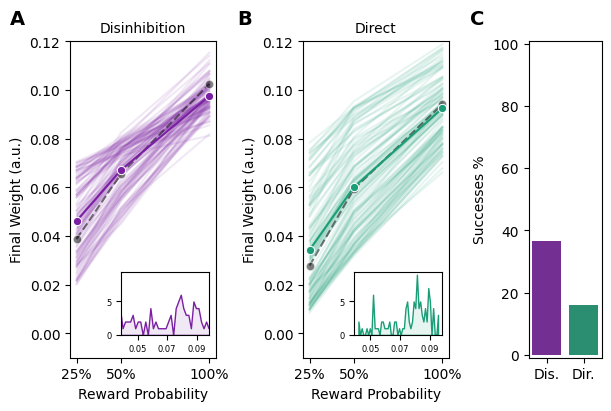

In [77]:
# Learning Results
import warnings
warnings.filterwarnings("ignore")

fig = plt.figure(figsize=(6, 4))
gs = GridSpec(1, 5, figure=fig)
axs = [fig.add_subplot(gs[0, 0:2]), fig.add_subplot(gs[0, 2:4]), fig.add_subplot(gs[0, 4:5])]
wCurve = weightsData.groupby(['Model', 'Reward Probability', 'ParSet']).agg('mean').reset_index().rename(columns={'wEnd':'Final Weight'})
wcDir = wCurve[wCurve['Model'] == 'FULLDIR']; wcInd = wCurve[wCurve['Model'] == 'FULLINH']

## Plot weights
sns.lineplot(wcDir, x='Reward Probability', y='Final Weight', hue = 'ParSet', ax=axs[1], palette=[sns.color_palette()[1]], alpha=.1, legend=False)
sns.lineplot(wcDir[wcDir['ParSet']== 100], x='Reward Probability', y='Final Weight', ax=axs[1], color='black', linestyle='--', marker='o', alpha=.5)
sns.lineplot(wcDir, x='Reward Probability', y='Final Weight', ax=axs[1], color=sns.color_palette()[1], marker='o')
sns.lineplot(wcInd, x='Reward Probability', y='Final Weight', hue = 'ParSet', ax=axs[0], palette=[sns.color_palette()[0]], alpha=.1, legend=False)
sns.lineplot(wcInd[wcInd['ParSet']== 100], x='Reward Probability', y='Final Weight', ax=axs[0], color='black', linestyle='--', marker='o', alpha=.5)
sns.lineplot(wcInd, x='Reward Probability', y='Final Weight', ax=axs[0], color=sns.color_palette()[0], marker='o')
axs[0].set_ylim((-.01, axs[0].get_ylim()[1])); axs[1].sharey(axs[0]); 
axs[0].set_ylabel('Final Weight (a.u.)'); axs[1].set_ylabel('Final Weight (a.u.)')
axs[0].set_title('Disinhibition', {'fontsize':rcParams["axes.labelsize"]}); panel_label(axs[0], 'A', -.41)
axs[1].set_title('Direct', {'fontsize':rcParams["axes.labelsize"]}); panel_label(axs[1], 'B', -.45)
axs[0].set_xticks([.25, .5, 1.]); axs[1].set_xticks([.25, .5, 1.])
axs[0].set_xticklabels(["25%", "50%", "100%"]); axs[1].set_xticklabels(["25%", "50%", "100%"])

#axs[0].set_xlim(-.001, 1.); axs[1].set_xlim(-.001, 1.)
ins0 = inset_axes(axs[0], width='60%', height='20%', loc='lower right', bbox_to_anchor=(0.0, 0.05, 1, 1), bbox_transform=axs[0].transAxes)
sns.histplot(slopes[slopes['Model']=='FULLINH']['slope'], ax = ins0, bins=50, element="poly", alpha = .1)
ins0.set_ylabel(''); ins0.set_xlabel(''); ins0.tick_params(labelsize=6)
ins1 = inset_axes(axs[1], width='60%', height='20%', loc='lower right', bbox_to_anchor=(0.0, 0.05, 1, 1), bbox_transform=axs[1].transAxes)
sns.histplot(slopes[slopes['Model']=='FULLDIR']['slope'], ax = ins1, bins=50, element="poly", alpha = .1, color='C1')
ins1.set_ylabel(''); ins1.set_xlabel(''); ins1.tick_params(labelsize=6)
ins0.sharey(ins1)
ins0.sharex(ins1)
ins0.set_xticks([.05, .07, .09])

#Successes
pairs = success[['Success', 'Strict']].rename(columns={'Success':'All'})
tmp = pairs.reset_index().melt(id_vars='Model') 
tmp = tmp[tmp['variable'] == 'Strict']
tmp['value'] = tmp['value'] * 100 / 101
tmp['Model'] = pd.Categorical(tmp['Model'], categories=['FULLINH', 'FULLDIR'], ordered=True)
sns.barplot(tmp, x = 'Model', y = 'value', hue='Model', ax=axs[2], legend=False, hue_order=['FULLINH', 'FULLDIR'])
axs[2].set_xlabel(''); axs[2].set_ylabel('Successes %'); panel_label(axs[2], 'C', -.8)
axs[2].set_ylim(-1, 101); axs[2].set_xticklabels(['Dis.', 'Dir.'])


for ax in axs+[ins0, ins1]:
    ax.relim(); ax.autoscale_view()
fig.set_constrained_layout(constrained=True)
fig.savefig('./Plots/learningTask.svg', format='svg')